# Hedging

This notebook is strictly for hedge/risk research. It builds a venue price panel, estimates covariance/PCA risk, decomposes inventory into hedgeable pair-spread vectors, and solves a cost-aware continuous hedge. It does not create prediction targets or IC tables.

In [1]:
from __future__ import annotations

import json
import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

if "notebooks" not in sys.path:
    sys.path.append("notebooks")

from advanced_features import build_feature_set, discover_datasets, latest_feature_date, minutes_to_periods
from hedging_tools import (
    latest_churnado_inventory,
    load_churnado_account_journal,
    load_churnado_market_catalog,
    rolling_hedge_simulation,
)

ROOT = Path(os.environ.get("MODL_WS_NORMALIZED_DIR", "/mnt/burner-archive/ws_normalized")).expanduser()
DATE = os.environ.get("MODL_VIEW_DATE") or latest_feature_date(ROOT)
DATE_TAG = datetime.strptime(DATE, "%Y-%m-%d").strftime("%y-%m-%d")
FEATURE_ROOT = Path(os.environ.get("MODL_WS_FEATURE_DIR", "/mnt/burner-archive/ws_features")).expanduser()
CHURNADO_ROOT = Path(os.environ.get("MODL_CHURNADO_ROOT", "/home/skier/Documents/churnado")).expanduser()
CHURNADO_ACCOUNT_JOURNAL = Path(
    os.environ.get(
        "MODL_CHURNADO_ACCOUNT_JOURNAL",
        str(CHURNADO_ROOT / "data/account/trend_mm_account_updates.jsonl"),
    )
).expanduser()
CHURNADO_CATALOG_DIR = Path(
    os.environ.get("MODL_CHURNADO_MARKET_CATALOG_DIR", str(CHURNADO_ROOT / "data/market-catalog"))
).expanduser()
CHURNADO_INSTRUMENT_MAP = json.loads(os.environ.get("MODL_CHURNADO_INSTRUMENT_MAP_JSON", "{}"))
BAR_MINUTES = int(os.environ.get("MODL_BAR_MINUTES", "5"))
HORIZONS = (5, 15, 30)
HEDGE_HORIZON_MINUTES = int(os.environ.get("MODL_HEDGE_HORIZON_MINUTES", "30"))
MAX_HEDGE_ABS_BTC = float(os.environ.get("MODL_MAX_HEDGE_ABS_BTC", "2.0"))
COST_AVERSION = float(os.environ.get("MODL_HEDGE_COST_AVERSION", "1.0"))
SPREAD_RIDGE = float(os.environ.get("MODL_SPREAD_RIDGE", "1e-6"))
ROLLING_WINDOW_BARS = int(os.environ.get("MODL_HEDGE_ROLLING_WINDOW_BARS", "8"))
SAVE_OUTPUTS = False

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 240)
pd.set_option("display.max_colwidth", 180)
pl.Config.set_tbl_cols(240)
pl.Config.set_tbl_rows(24)

DATASETS = discover_datasets(ROOT, DATE_TAG)
if not DATASETS:
    raise FileNotFoundError(f"No normalized Parquet files found under {ROOT} for {DATE}")

ROOT, DATE, DATE_TAG, BAR_MINUTES, HEDGE_HORIZON_MINUTES, ROLLING_WINDOW_BARS, len(DATASETS)

(PosixPath('/mnt/burner-archive/ws_normalized'),
 '2026-06-30',
 '26-06-30',
 5,
 30,
 8,
 14)

## Build Feature Set

In [2]:
feature_set = build_feature_set(DATASETS, horizons=HORIZONS, bar_minutes=BAR_MINUTES)
feature_matrix = feature_set.feature_matrix
reference_price = feature_set.reference_price
print("feature_matrix", feature_matrix.shape)
feature_matrix.tail(5)

feature_matrix (21, 436)


,trade_flow_imbalance_bitfinex,trade_flow_imbalance_hibachi,trade_flow_imbalance_hyperliquid,trade_trade_count_bitfinex,trade_trade_count_hibachi,trade_trade_count_hyperliquid,trade_volume_bitfinex,trade_volume_hibachi,trade_volume_hyperliquid,trade_vwap_bitfinex,trade_vwap_hibachi,trade_vwap_hyperliquid,book_depth_imbalance_bitfinex_updates,book_depth_imbalance_hyperliquid,book_mid_bitfinex_updates,book_mid_hibachi,book_mid_hyperliquid,book_spread_bps_bitfinex_updates,book_spread_bps_hibachi,book_spread_bps_hyperliquid,book_top_imbalance_hibachi,option_tick_count,active_options,median_mark_iv,median_index_price,open_interest_sum,estimated_funding_rate,funding_updates,mid_hibachi_minus_hyperliquid,mid_hibachi_minus_hyperliquid_bps,spread_bps_hibachi_minus_hyperliquid,cross_venue_flow_imbalance_mean,cross_venue_flow_imbalance_std,cross_venue_volume_sum,cross_venue_spread_bps_mean,cross_venue_spread_bps_std,reference_price,log_price,ret_5m,ret_15m,ret_30m,ret_60m,rv_5m,bpv_5m,jump_var_5m,jump_share_5m,rv_15m,bpv_15m,jump_var_15m,jump_share_15m,rv_30m,bpv_30m,jump_var_30m,jump_share_30m,rv_5m_over_30m,bpv_5m_over_rv_5m,iv_0_7d,iv_30_90d,iv_7_30d,iv_90d_plus,iv_0_7d_count,iv_30_90d_count,iv_7_30d_count,iv_90d_plus_count,atm_call,atm_put,atm_put_call_iv_spread,term_slope_30_90_minus_0_7,term_slope_90_plus_minus_7_30,term_curvature,short_iv_decimal,smile_atm_call_iv,smile_atm_put_iv,smile_otm_call_iv,smile_otm_put_iv,smile_atm_call_iv_count,smile_atm_put_iv_count,smile_otm_call_iv_count,smile_otm_put_iv_count,smile_put_wing_minus_atm,smile_call_wing_minus_atm,smile_risk_reversal_proxy,smile_butterfly_proxy,basis_fut_0_7d,basis_fut_30_90d,basis_fut_7_30d,basis_fut_90d_plus,basis_fut_perp,basis_fut_0_7d_annualized,basis_fut_30_90d_annualized,basis_fut_7_30d_annualized,basis_fut_90d_plus_annualized,basis_fut_perp_annualized,basis_fut_0_7d_count,basis_fut_30_90d_count,basis_fut_7_30d_count,basis_fut_90d_plus_count,basis_fut_perp_count,basis_future_basis_slope_30_90_minus_0_7,basis_future_basis_slope_90_plus_minus_7_30,trade_flow_imbalance_bitfinex_diff_5m,trade_flow_imbalance_bitfinex_mean_5m,trade_flow_imbalance_bitfinex_z_5m,trade_flow_imbalance_bitfinex_mean_15m,trade_flow_imbalance_bitfinex_z_15m,trade_flow_imbalance_bitfinex_mean_30m,trade_flow_imbalance_bitfinex_z_30m,trade_flow_imbalance_hibachi_diff_5m,trade_flow_imbalance_hibachi_mean_5m,trade_flow_imbalance_hibachi_z_5m,trade_flow_imbalance_hibachi_mean_15m,trade_flow_imbalance_hibachi_z_15m,trade_flow_imbalance_hibachi_mean_30m,trade_flow_imbalance_hibachi_z_30m,trade_flow_imbalance_hyperliquid_diff_5m,trade_flow_imbalance_hyperliquid_mean_5m,trade_flow_imbalance_hyperliquid_z_5m,trade_flow_imbalance_hyperliquid_mean_15m,trade_flow_imbalance_hyperliquid_z_15m,trade_flow_imbalance_hyperliquid_mean_30m,...,jump_share_5m_z_30m,rv_15m_diff_5m,rv_15m_mean_5m,rv_15m_z_5m,rv_15m_mean_15m,rv_15m_z_15m,rv_15m_mean_30m,rv_15m_z_30m,bpv_15m_diff_5m,bpv_15m_mean_5m,bpv_15m_z_5m,bpv_15m_mean_15m,bpv_15m_z_15m,bpv_15m_mean_30m,bpv_15m_z_30m,jump_var_15m_diff_5m,jump_var_15m_mean_5m,jump_var_15m_z_5m,jump_var_15m_mean_15m,jump_var_15m_z_15m,jump_var_15m_mean_30m,jump_var_15m_z_30m,jump_share_15m_diff_5m,jump_share_15m_mean_5m,jump_share_15m_z_5m,jump_share_15m_mean_15m,jump_share_15m_z_15m,jump_share_15m_mean_30m,jump_share_15m_z_30m,rv_30m_diff_5m,rv_30m_mean_5m,rv_30m_z_5m,rv_30m_mean_15m,rv_30m_z_15m,rv_30m_mean_30m,rv_30m_z_30m,bpv_30m_diff_5m,bpv_30m_mean_5m,bpv_30m_z_5m,bpv_30m_mean_15m,bpv_30m_z_15m,bpv_30m_mean_30m,bpv_30m_z_30m,jump_var_30m_diff_5m,jump_var_30m_mean_5m,jump_var_30m_z_5m,jump_var_30m_mean_15m,jump_var_30m_z_15m,jump_var_30m_mean_30m,jump_var_30m_z_30m,jump_share_30m_diff_5m,jump_share_30m_mean_5m,jump_share_30m_z_5m,jump_share_30m_mean_15m,jump_share_30m_z_15m,jump_share_30m_mean_30m,jump_share_30m_z_30m,rv_5m_over_30m_diff_5m,rv_5m_over_30m_mean_5m,rv_5m_over_30m_z_5m,rv_5m_over_30m_mean_15m,rv_5m_over_30m_z_15m,rv_5m_over_30m_mean_30m,rv_5m_over_30m_z_30m,bpv_5m_o

## Hedge Universe

In [3]:
def first_available(frame: pd.DataFrame, columns: list[str]) -> pd.Series | None:
    for column in columns:
        if column in frame and frame[column].notna().sum() >= 3:
            return frame[column].astype(float)
    return None


def build_hedge_universe(frame: pd.DataFrame, reference: pd.Series) -> tuple[pd.DataFrame, pd.DataFrame]:
    specs = [
        {
            "instrument": "bitfinex_spot",
            "venue": "bitfinex",
            "kind": "spot",
            "price_cols": ["book_mid_bitfinex_updates", "trade_vwap_bitfinex"],
            "spread_col": "book_spread_bps_bitfinex_updates",
            "volume_col": "trade_volume_bitfinex",
            "funding_col": None,
            "basis_col": None,
        },
        {
            "instrument": "hibachi_perp",
            "venue": "hibachi",
            "kind": "perp",
            "price_cols": ["book_mid_hibachi", "trade_vwap_hibachi"],
            "spread_col": "book_spread_bps_hibachi",
            "volume_col": "trade_volume_hibachi",
            "funding_col": "estimated_funding_rate",
            "basis_col": None,
        },
        {
            "instrument": "hyperliquid_ubtc",
            "venue": "hyperliquid",
            "kind": "spot_or_perp_proxy",
            "price_cols": ["book_mid_hyperliquid", "trade_vwap_hyperliquid"],
            "spread_col": "book_spread_bps_hyperliquid",
            "volume_col": "trade_volume_hyperliquid",
            "funding_col": None,
            "basis_col": None,
        },
    ]

    prices = {}
    rows = []
    for spec in specs:
        price = first_available(frame, spec["price_cols"])
        if price is None:
            continue
        prices[spec["instrument"]] = price
        spread = frame.get(spec["spread_col"], pd.Series(index=frame.index, dtype=float)).astype(float)
        volume = frame.get(spec["volume_col"], pd.Series(index=frame.index, dtype=float)).astype(float)
        funding = frame.get(spec["funding_col"], pd.Series(index=frame.index, dtype=float)).astype(float) if spec["funding_col"] else pd.Series(index=frame.index, dtype=float)
        rows.append(
            {
                "instrument": spec["instrument"],
                "venue": spec["venue"],
                "kind": spec["kind"],
                "price_source": next(column for column in spec["price_cols"] if column in frame and frame[column].notna().sum() >= 3),
                "spread_bps_median": spread.replace([np.inf, -np.inf], np.nan).median(),
                "volume_median": volume.replace([np.inf, -np.inf], np.nan).median(),
                "funding_rate_median": funding.replace([np.inf, -np.inf], np.nan).median(),
            }
        )

    if "basis_fut_perp" in frame and reference.notna().sum() >= 3:
        basis = frame["basis_fut_perp"].astype(float).reindex(reference.index).ffill()
        deribit_price = reference.astype(float).reindex(frame.index).ffill() * (1.0 + basis / 10_000.0)
        if deribit_price.notna().sum() >= 3:
            prices["deribit_perp_proxy"] = deribit_price
            rows.append(
                {
                    "instrument": "deribit_perp_proxy",
                    "venue": "deribit",
                    "kind": "perp_proxy",
                    "price_source": "reference_price * (1 + basis_fut_perp / 10000)",
                    "spread_bps_median": np.nan,
                    "volume_median": np.nan,
                    "funding_rate_median": np.nan,
                }
            )

    price_panel = pd.DataFrame(prices).sort_index().ffill()
    universe = pd.DataFrame(rows).set_index("instrument") if rows else pd.DataFrame()
    return price_panel, universe


price_panel, hedge_universe = build_hedge_universe(feature_matrix, reference_price)
hedge_universe

,venue,kind,price_source,spread_bps_median,volume_median,funding_rate_median
instrument,,,,,,
bitfinex_spot,bitfinex,spot,book_mid_bitfinex_updates,4.959574,1.136589,NaN
hibachi_perp,hibachi,perp,book_mid_hibachi,0.082350,0.069181,0.000038
hyperliquid_ubtc,hyperliquid,spot_or_perp_proxy,book_mid_hyperliquid,0.252336,0.291220,NaN
deribit_perp_proxy,deribit,perp_proxy,reference_price * (1 + basis_fut_perp / 10000),NaN,NaN,NaN


In [4]:
price_panel.tail(20)

,bitfinex_spot,hibachi_perp,hyperliquid_ubtc,deribit_perp_proxy
minute,,,,
2026-06-30 03:25:00,59854.322917,59831.423963,59782.300000,59832.635026
2026-06-30 03:30:00,59788.116595,59769.251564,59721.678571,59770.918025
2026-06-30 03:35:00,59765.383309,59740.519747,59694.973214,59744.757737
2026-06-30 03:40:00,59743.570842,59721.902273,59673.690909,59726.461539
2026-06-30 03:45:00,59661.200387,59645.717255,59595.928571,59653.679637
2026-06-30 03:50:00,59648.366613,59634.699798,59580.848214,59642.705238
2026-06-30 03:55:00,59610.750784,59594.077475,59542.527273,59601.293639
2026-06-30 04:00:00,59576.976882,59552.554798,59505.446429,59562.297543
2026-06-30 04:05:00,59494.461496,59478.792281,59432.972727,59489.435678


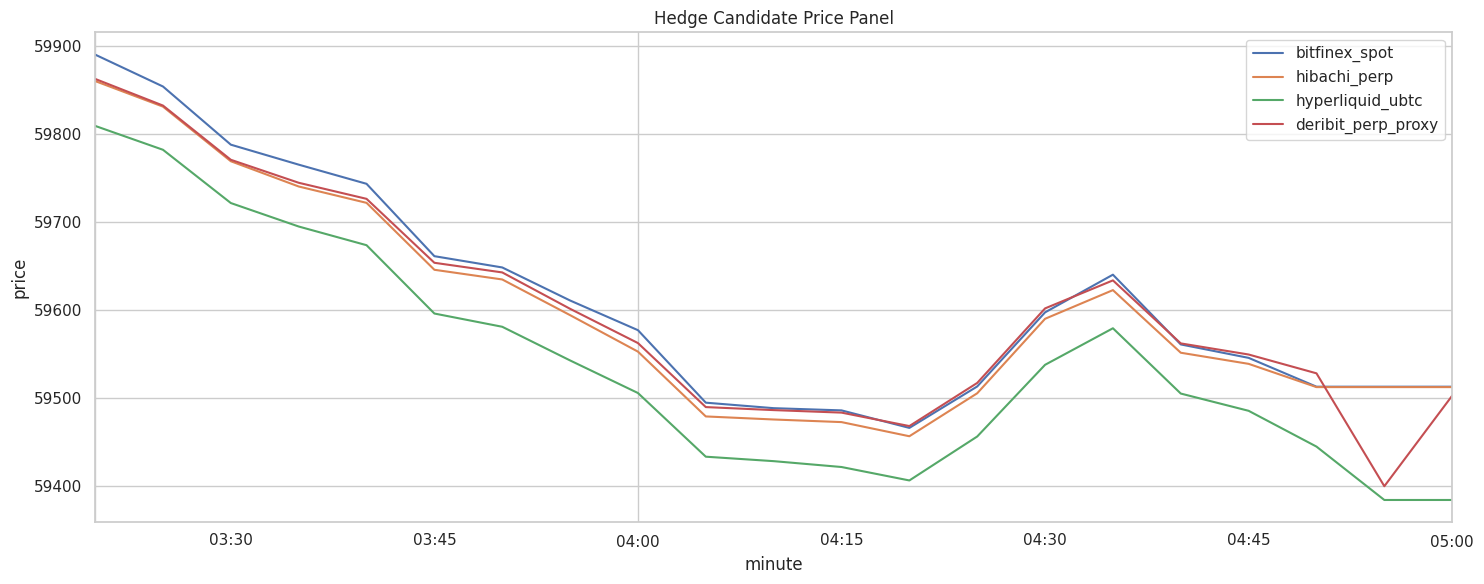

In [5]:
if not price_panel.empty:
    ax = price_panel.plot(figsize=(15, 6), linewidth=1.5)
    ax.set_title("Hedge Candidate Price Panel")
    ax.set_ylabel("price")
    plt.tight_layout()
else:
    print("No hedge candidate prices available")

## Returns, Covariance, And PCA

In [6]:
def build_return_panel(prices: pd.DataFrame, min_obs: int = 5) -> pd.DataFrame:
    cleaned = prices.replace([np.inf, -np.inf], np.nan).ffill().dropna(how="all")
    returns = np.log(cleaned).diff().replace([np.inf, -np.inf], np.nan)
    keep = returns.notna().sum() >= min_obs
    returns = returns.loc[:, keep]
    return returns.dropna(how="any")


def shrink_covariance(returns: pd.DataFrame) -> pd.DataFrame:
    if returns.empty:
        return pd.DataFrame()
    clean = returns.replace([np.inf, -np.inf], np.nan).dropna()
    columns = clean.columns
    if clean.shape[0] >= max(4, clean.shape[1] + 1) and clean.shape[1] > 1:
        cov = LedoitWolf().fit(clean.to_numpy()).covariance_
    else:
        sample = clean.cov().fillna(0.0).to_numpy()
        diag = np.diag(np.diag(sample))
        cov = 0.50 * sample + 0.50 * diag
    cov = np.asarray(cov, dtype=float)
    cov = (cov + cov.T) / 2.0
    cov += np.eye(cov.shape[0]) * 1e-12
    return pd.DataFrame(cov, index=columns, columns=columns)


def pca_from_cov(cov: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    if cov.empty:
        return pd.DataFrame(), pd.DataFrame()
    values, vectors = np.linalg.eigh(cov.to_numpy())
    order = np.argsort(values)[::-1]
    values = values[order]
    vectors = vectors[:, order]
    explained = values / values.sum() if values.sum() > 0 else np.zeros_like(values)
    components = pd.DataFrame(vectors, index=cov.index, columns=[f"pc{i + 1}" for i in range(len(values))])
    summary = pd.DataFrame(
        {
            "eigenvalue": values,
            "explained_variance": explained,
            "cumulative_explained": np.cumsum(explained),
        },
        index=components.columns,
    )
    return summary, components


returns = build_return_panel(price_panel)
cov_1bar = shrink_covariance(returns)
horizon_periods = minutes_to_periods(HEDGE_HORIZON_MINUTES, BAR_MINUTES)
cov_horizon = cov_1bar * horizon_periods
pca_summary, pca_loadings = pca_from_cov(cov_horizon)
print("returns", returns.shape)
print("cov", cov_horizon.shape)
pca_summary

returns (20, 4)
cov (4, 4)


,eigenvalue,explained_variance,cumulative_explained
pc1,1.020947e-05,0.769709,0.769709
pc2,1.786374e-06,0.134678,0.904386
pc3,6.682185e-07,0.050378,0.954765
pc4,6.000055e-07,0.045235,1.000000


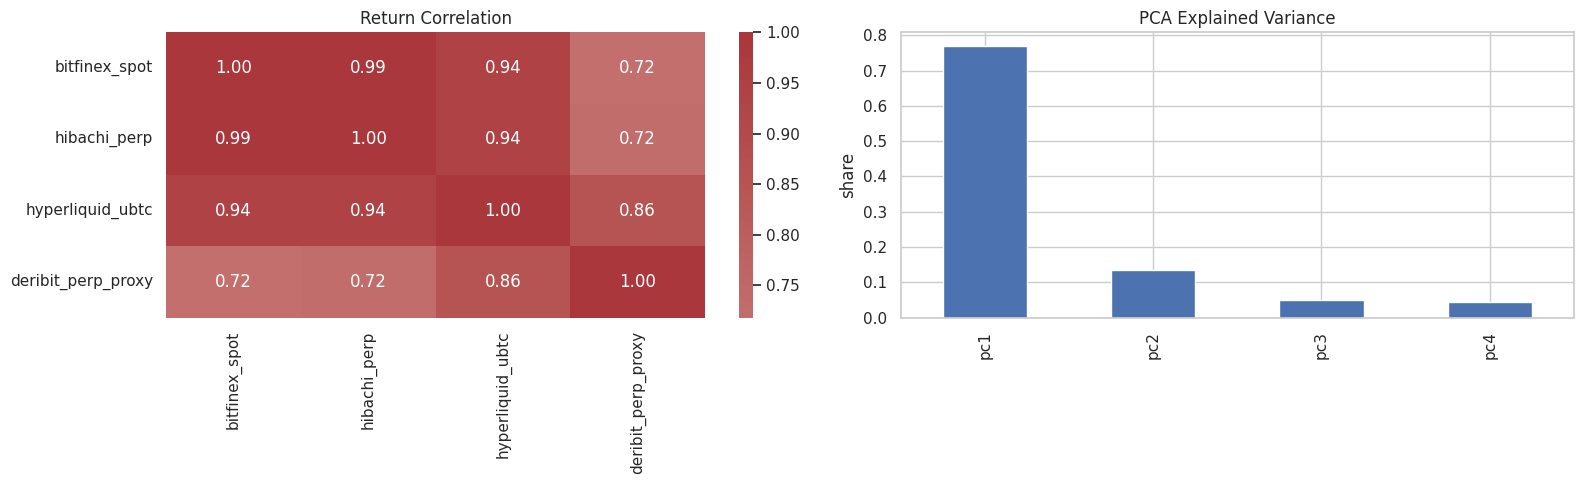

In [7]:
if not returns.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.heatmap(returns.corr(), cmap="vlag", center=0, annot=True, fmt=".2f", ax=axes[0])
    axes[0].set_title("Return Correlation")
    if not pca_summary.empty:
        pca_summary["explained_variance"].plot(kind="bar", ax=axes[1])
        axes[1].set_title("PCA Explained Variance")
        axes[1].set_ylabel("share")
    plt.tight_layout()
else:
    print("Not enough returns for covariance/PCA")

In [8]:
pca_loadings

,pc1,pc2,pc3,pc4
bitfinex_spot,-0.475452,-0.457096,0.284836,-0.695612
hibachi_perp,-0.450665,-0.423277,0.320779,0.717522
hyperliquid_ubtc,-0.483743,-0.088837,-0.870074,0.032741
deribit_perp_proxy,-0.580378,0.777179,0.242777,-0.014594


## Live Churnado Account Inventory

In [ ]:
account_frames = load_churnado_account_journal(CHURNADO_ACCOUNT_JOURNAL)
churnado_catalog = load_churnado_market_catalog(CHURNADO_CATALOG_DIR)
live_inventory, live_position_detail = latest_churnado_inventory(
    account_frames["positions"],
    list(cov_horizon.columns),
    instrument_map=CHURNADO_INSTRUMENT_MAP,
    catalog=churnado_catalog,
)

account_status = pd.DataFrame(
    [
        {"item": "journal_path", "value": str(CHURNADO_ACCOUNT_JOURNAL)},
        {"item": "journal_exists", "value": CHURNADO_ACCOUNT_JOURNAL.exists()},
        {"item": "updates", "value": len(account_frames["updates"])},
        {"item": "positions", "value": len(account_frames["positions"])},
        {"item": "fills", "value": len(account_frames["fills"])},
        {"item": "catalog_rows", "value": len(churnado_catalog)},
        {"item": "inventory_source", "value": "churnado" if not live_position_detail.empty else "example_or_env"},
    ]
)
display(account_status)

if live_position_detail.empty:
    print(f"No churnado account positions loaded from {CHURNADO_ACCOUNT_JOURNAL}")
else:
    display(live_inventory.rename("live_inventory_btc").to_frame())
    detail_cols = [
        col
        for col in [
            "recorded_at",
            "venue",
            "venue_id",
            "instrument_id",
            "symbol",
            "qty",
            "hedge_instrument",
            "mapped_qty_btc",
        ]
        if col in live_position_detail
    ]
    display(live_position_detail[detail_cols].tail(20))


## Inventory Vector

In [9]:
def configured_inventory(
    columns: list[str],
    live_inventory: pd.Series | None = None,
    use_live: bool = False,
) -> pd.Series:
    raw = os.environ.get("MODL_HEDGE_INVENTORY_JSON")
    if raw:
        data = json.loads(raw)
        inventory = pd.Series(data, dtype=float)
        source = "MODL_HEDGE_INVENTORY_JSON"
    elif use_live and live_inventory is not None:
        inventory = live_inventory.copy()
        source = "churnado_account_journal"
    else:
        default = {
            "bitfinex_spot": 1.00,
            "hibachi_perp": -0.35,
            "hyperliquid_ubtc": 0.15,
            "deribit_perp_proxy": 0.00,
        }
        inventory = pd.Series(default, dtype=float)
        source = "example"
    inventory = inventory.reindex(columns).fillna(0.0)
    inventory.attrs["source"] = source
    return inventory


use_live_inventory = "live_position_detail" in globals() and not live_position_detail.empty
live_inventory_for_config = live_inventory if "live_inventory" in globals() else None
inventory = configured_inventory(
    list(cov_horizon.columns),
    live_inventory_for_config,
    use_live=use_live_inventory,
)
inventory.rename("inventory_btc").to_frame().assign(source=inventory.attrs.get("source"))


,inventory_btc
bitfinex_spot,1.00
hibachi_perp,-0.35
hyperliquid_ubtc,0.15
deribit_perp_proxy,0.00


In [10]:
if not cov_horizon.empty:
    common_mode = pca_loadings["pc1"] if "pc1" in pca_loadings else pd.Series(index=inventory.index, dtype=float)
    pc_exposure = pca_loadings.T @ inventory
    inventory_diagnostics = pd.DataFrame(
        {
            "inventory_btc": inventory,
            "pc1_loading": common_mode,
            "risk_gradient": cov_horizon @ inventory,
        }
    )
    display(inventory_diagnostics)
    display(pc_exposure.rename("inventory_pc_exposure").to_frame())
else:
    print("No covariance matrix available")

,inventory_btc,pc1_loading,risk_gradient
bitfinex_spot,1.00,-0.475452,0.000003
hibachi_perp,-0.35,-0.450665,0.000002
hyperliquid_ubtc,0.15,-0.483743,0.000002
deribit_perp_proxy,0.00,-0.580378,0.000002


,inventory_pc_exposure
pc1,-0.390281
pc2,-0.322275
pc3,0.042052
pc4,-0.941834


## Mean-Reverting Pair-Spread Reduction

In [11]:
def pair_spread_betas(columns: list[str]) -> pd.DataFrame:
    betas = []
    names = []
    for i, left in enumerate(columns):
        for right in columns[i + 1 :]:
            beta = pd.Series(0.0, index=columns)
            beta[left] = 1.0
            beta[right] = -1.0
            betas.append(beta)
            names.append(f"{left}_minus_{right}")
    if not betas:
        return pd.DataFrame(index=columns)
    return pd.DataFrame(betas, index=names).T


def reduce_by_spread_vectors(inventory: pd.Series, cov: pd.DataFrame, ridge: float = 1e-6) -> tuple[pd.Series, pd.Series]:
    if cov.empty or inventory.empty:
        return pd.Series(dtype=float), inventory.copy()
    betas = pair_spread_betas(list(cov.columns))
    if betas.empty:
        return pd.Series(dtype=float), inventory.copy()
    sigma = cov.reindex(index=inventory.index, columns=inventory.index).to_numpy(dtype=float)
    b = betas.reindex(index=inventory.index).to_numpy(dtype=float)
    q = inventory.to_numpy(dtype=float)
    lhs = b.T @ sigma @ b + np.eye(b.shape[1]) * ridge
    rhs = b.T @ sigma @ q
    weights = np.linalg.solve(lhs, rhs)
    hedgeable = b @ weights
    residual = q - hedgeable
    return pd.Series(weights, index=betas.columns, name="spread_weight"), pd.Series(residual, index=inventory.index, name="residual_btc")


spread_weights, spread_residual = reduce_by_spread_vectors(inventory, cov_horizon, ridge=SPREAD_RIDGE)
spread_summary = pd.DataFrame({"inventory_btc": inventory, "spread_residual_btc": spread_residual})
spread_weights.sort_values(key=lambda s: s.abs(), ascending=False).to_frame().head(20)

,spread_weight
bitfinex_spot_minus_hibachi_perp,0.267789
bitfinex_spot_minus_hyperliquid_ubtc,0.169117
bitfinex_spot_minus_deribit_perp_proxy,0.159609
hibachi_perp_minus_deribit_perp_proxy,-0.108180
hibachi_perp_minus_hyperliquid_ubtc,-0.098671
hyperliquid_ubtc_minus_deribit_perp_proxy,-0.009508


In [12]:
def portfolio_variance(exposure: pd.Series, cov: pd.DataFrame) -> float:
    aligned = exposure.reindex(cov.index).fillna(0.0).to_numpy(dtype=float)
    sigma = cov.to_numpy(dtype=float)
    return float(aligned @ sigma @ aligned)


risk_before = portfolio_variance(inventory, cov_horizon) if not cov_horizon.empty else np.nan
risk_after_spread = portfolio_variance(spread_residual, cov_horizon) if not cov_horizon.empty else np.nan
risk_summary = pd.DataFrame(
    [
        {"portfolio": "inventory", "variance": risk_before, "vol_bps": np.sqrt(risk_before) * 10_000 if risk_before >= 0 else np.nan},
        {"portfolio": "after_pair_spread_reduction", "variance": risk_after_spread, "vol_bps": np.sqrt(risk_after_spread) * 10_000 if risk_after_spread >= 0 else np.nan},
    ]
)
risk_summary

,portfolio,variance,vol_bps
0,inventory,0.000002,15.079953
1,after_pair_spread_reduction,0.000002,12.703558


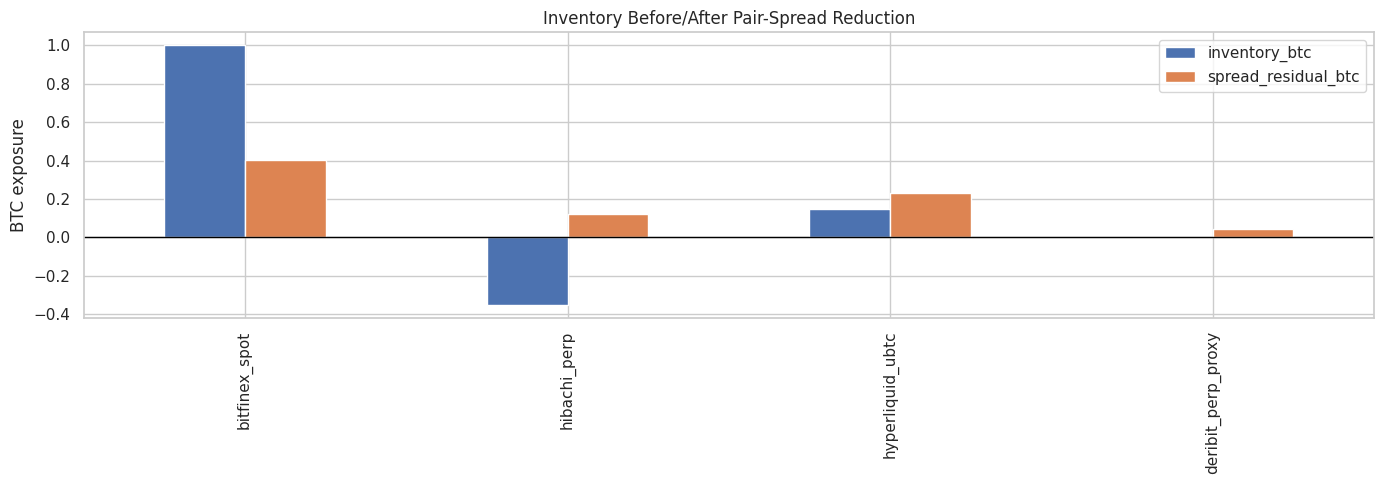

In [13]:
if not spread_summary.empty:
    ax = spread_summary.plot(kind="bar", figsize=(14, 5))
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title("Inventory Before/After Pair-Spread Reduction")
    ax.set_ylabel("BTC exposure")
    plt.tight_layout()

## Venue Cost Estimates

In [14]:
def latest_or_median(series: pd.Series, fallback: float = np.nan) -> float:
    clean = pd.Series(series).replace([np.inf, -np.inf], np.nan).dropna()
    if clean.empty:
        return fallback
    return float(clean.tail(min(12, len(clean))).median())


def estimate_hedge_costs(frame: pd.DataFrame, universe: pd.DataFrame, horizon_minutes: int) -> pd.DataFrame:
    rows = []
    for instrument, row in universe.iterrows():
        spread_bps = row.get("spread_bps_median")
        if not np.isfinite(spread_bps):
            spread_bps = 2.0
        half_spread_bps = max(float(spread_bps) / 2.0, 0.0)

        funding_rate = row.get("funding_rate_median")
        funding_carry_bps = 0.0
        if np.isfinite(funding_rate):
            funding_carry_bps = abs(float(funding_rate)) * 10_000.0 * horizon_minutes / (8 * 60)

        basis_carry_bps = 0.0
        if instrument == "deribit_perp_proxy" and "basis_fut_perp" in frame:
            basis_carry_bps = abs(latest_or_median(frame["basis_fut_perp"], fallback=0.0)) * 0.10

        liquidity_penalty_bps = 0.0
        volume = row.get("volume_median")
        if np.isfinite(volume) and volume > 0:
            liquidity_penalty_bps = min(2.0, 1.0 / np.sqrt(float(volume)))
        elif row.get("kind") == "perp_proxy":
            liquidity_penalty_bps = 1.0

        total = half_spread_bps + funding_carry_bps + basis_carry_bps + liquidity_penalty_bps
        rows.append(
            {
                "instrument": instrument,
                "half_spread_bps": half_spread_bps,
                "funding_carry_bps": funding_carry_bps,
                "basis_penalty_bps": basis_carry_bps,
                "liquidity_penalty_bps": liquidity_penalty_bps,
                "total_cost_bps": total,
            }
        )
    return pd.DataFrame(rows).set_index("instrument").sort_values("total_cost_bps")


hedge_costs = estimate_hedge_costs(feature_matrix, hedge_universe, HEDGE_HORIZON_MINUTES)
hedge_costs

,half_spread_bps,funding_carry_bps,basis_penalty_bps,liquidity_penalty_bps,total_cost_bps
instrument,,,,,
hyperliquid_ubtc,0.126168,0.00000,0.000000,1.85306,1.979228
hibachi_perp,0.041175,0.02375,0.000000,2.00000,2.064925
deribit_perp_proxy,1.000000,0.00000,0.180555,1.00000,2.180555
bitfinex_spot,2.479787,0.00000,0.000000,0.93799,3.417777


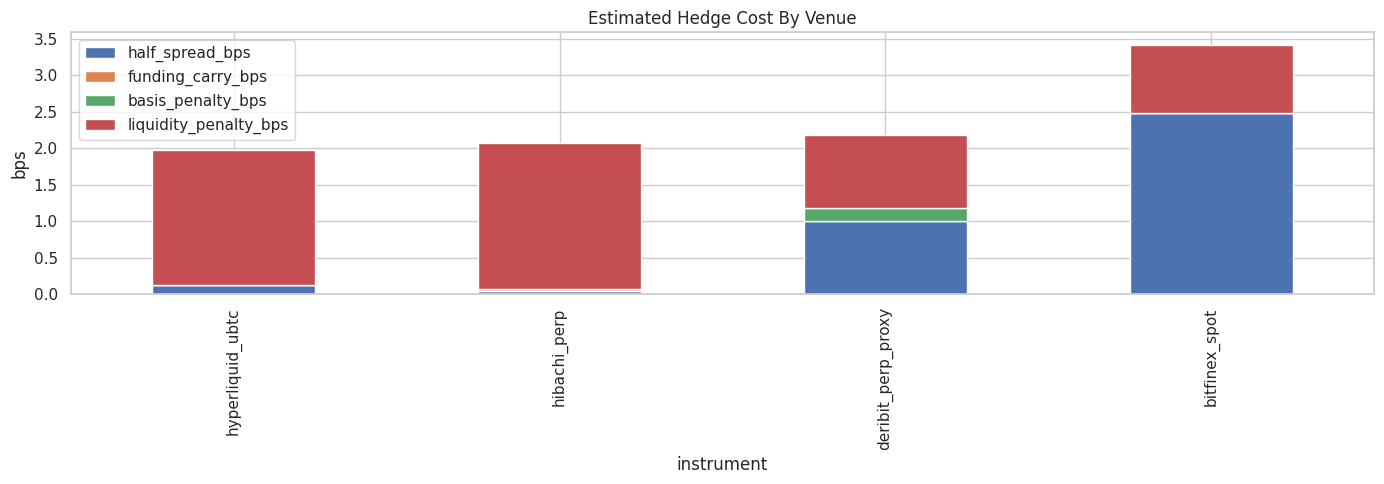

In [15]:
if not hedge_costs.empty:
    ax = hedge_costs[["half_spread_bps", "funding_carry_bps", "basis_penalty_bps", "liquidity_penalty_bps"]].plot(
        kind="bar",
        stacked=True,
        figsize=(14, 5),
    )
    ax.set_title("Estimated Hedge Cost By Venue")
    ax.set_ylabel("bps")
    plt.tight_layout()

## Cost-Aware Continuous Hedge

In [16]:
def solve_cost_aware_hedge(
    inventory: pd.Series,
    cov: pd.DataFrame,
    costs: pd.Series,
    max_abs_btc: float = 2.0,
    cost_aversion: float = 1.0,
) -> tuple[pd.Series, pd.Series, pd.DataFrame]:
    columns = list(cov.columns)
    q = inventory.reindex(columns).fillna(0.0).to_numpy(dtype=float)
    sigma = cov.reindex(index=columns, columns=columns).to_numpy(dtype=float)
    cost = costs.reindex(columns).fillna(costs.median() if len(costs) else 1.0).to_numpy(dtype=float)

    def smooth_abs(x: np.ndarray) -> np.ndarray:
        return np.sqrt(x * x + 1e-8)

    def objective(x: np.ndarray) -> float:
        residual = q + x
        risk_bps2 = float(residual @ sigma @ residual) * 1e8
        trade_cost_bps = float(np.sum(cost * smooth_abs(x)))
        return risk_bps2 + cost_aversion * trade_cost_bps

    bounds = [(-max_abs_btc, max_abs_btc) for _ in columns]
    x0 = np.zeros(len(columns), dtype=float)
    result = minimize(objective, x0=x0, method="L-BFGS-B", bounds=bounds)
    hedge = pd.Series(result.x, index=columns, name="hedge_trade_btc")
    residual = pd.Series(q + result.x, index=columns, name="residual_btc")
    diagnostics = pd.DataFrame(
        [
            {"metric": "success", "value": bool(result.success)},
            {"metric": "objective", "value": float(result.fun)},
            {"metric": "iterations", "value": int(result.nit)},
            {"metric": "message", "value": str(result.message)},
        ]
    )
    return hedge, residual, diagnostics


hedge_trade, residual_after_hedge, optimizer_diagnostics = solve_cost_aware_hedge(
    inventory,
    cov_horizon,
    hedge_costs["total_cost_bps"],
    max_abs_btc=MAX_HEDGE_ABS_BTC,
    cost_aversion=COST_AVERSION,
)
optimizer_diagnostics

,metric,value
0,success,True
1,objective,4.37108
2,iterations,18
3,message,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [17]:
hedge_plan = pd.DataFrame(
    {
        "inventory_btc": inventory,
        "hedge_trade_btc": hedge_trade,
        "residual_btc": residual_after_hedge,
        "estimated_cost_bps": hedge_costs["total_cost_bps"].reindex(inventory.index),
    }
)
hedge_plan

,inventory_btc,hedge_trade_btc,residual_btc,estimated_cost_bps
bitfinex_spot,1.00,-0.979905,0.020095,3.417777
hibachi_perp,-0.35,0.324872,-0.025128,2.064925
hyperliquid_ubtc,0.15,-0.143683,0.006317,1.979228
deribit_perp_proxy,0.00,-0.000093,-0.000093,2.180555


In [18]:
risk_after_live_hedge = portfolio_variance(residual_after_hedge, cov_horizon) if not cov_horizon.empty else np.nan
trade_cost_bps = (hedge_trade.abs() * hedge_costs["total_cost_bps"].reindex(hedge_trade.index)).sum()
hedge_risk_summary = pd.DataFrame(
    [
        {"portfolio": "inventory", "variance": risk_before, "vol_bps": np.sqrt(risk_before) * 10_000 if risk_before >= 0 else np.nan, "trade_cost_bps": 0.0},
        {"portfolio": "after_pair_spread_reduction", "variance": risk_after_spread, "vol_bps": np.sqrt(risk_after_spread) * 10_000 if risk_after_spread >= 0 else np.nan, "trade_cost_bps": np.nan},
        {"portfolio": "after_cost_aware_hedge", "variance": risk_after_live_hedge, "vol_bps": np.sqrt(risk_after_live_hedge) * 10_000 if risk_after_live_hedge >= 0 else np.nan, "trade_cost_bps": trade_cost_bps},
    ]
)
hedge_risk_summary

,portfolio,variance,vol_bps,trade_cost_bps
0,inventory,2.274050e-06,15.079953,0.00000
1,after_pair_spread_reduction,1.613804e-06,12.703558,NaN
2,after_cost_aware_hedge,6.646503e-10,0.257808,4.30452


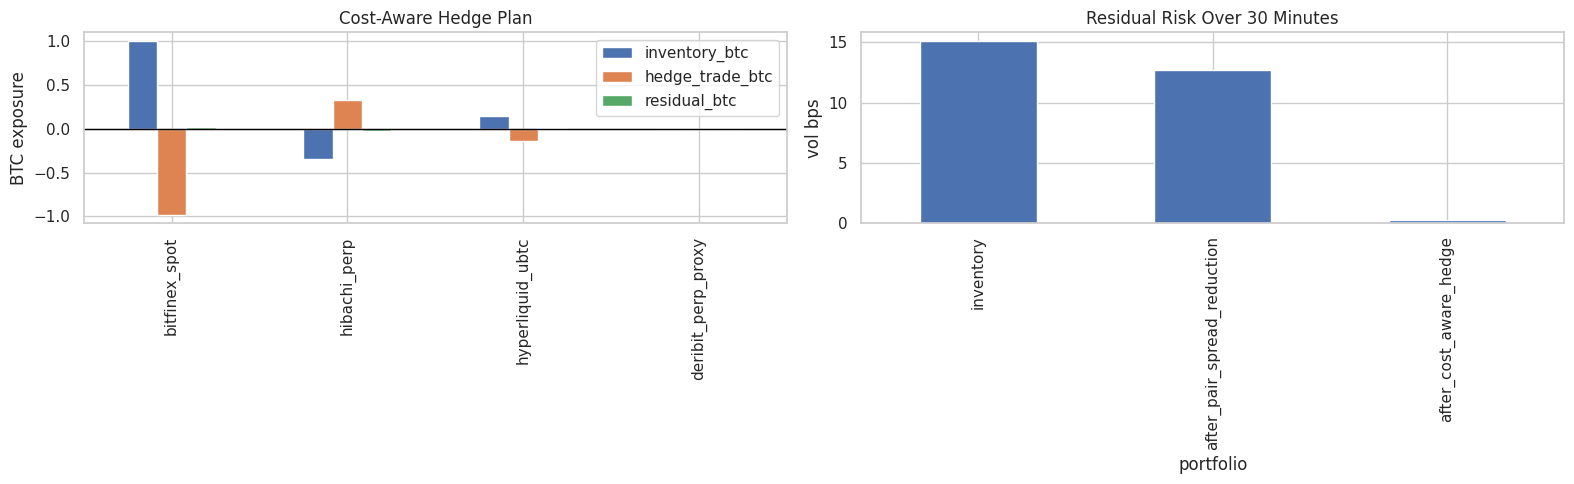

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
hedge_plan[["inventory_btc", "hedge_trade_btc", "residual_btc"]].plot(kind="bar", ax=axes[0])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Cost-Aware Hedge Plan")
axes[0].set_ylabel("BTC exposure")
hedge_risk_summary.set_index("portfolio")["vol_bps"].plot(kind="bar", ax=axes[1])
axes[1].set_title(f"Residual Risk Over {HEDGE_HORIZON_MINUTES} Minutes")
axes[1].set_ylabel("vol bps")
plt.tight_layout()

## Rolling Hedge Simulation

This re-estimates covariance on a trailing window, solves the hedge using information available before the next bar, and applies the next realized return with turnover costs. It is still a tiny-sample pipeline check until we have full days.

In [20]:
rolling_window_bars = min(ROLLING_WINDOW_BARS, max(2, len(returns) // 2))
rolling_sim = rolling_hedge_simulation(
    returns,
    inventory,
    hedge_costs["total_cost_bps"],
    window_bars=rolling_window_bars,
    horizon_periods=horizon_periods,
    max_abs_btc=MAX_HEDGE_ABS_BTC,
    cost_aversion=COST_AVERSION,
)
print(f"rolling_window_bars={rolling_window_bars}")
rolling_sim.tail(20)

rolling_window_bars=8


,unhedged_pnl_bps,hedged_pnl_bps_after_cost,turnover_cost_bps,turnover_btc,risk_before_vol_bps,risk_after_vol_bps
timestamp,,,,,,
2026-06-30 04:05:00,-11.349999,-4.130583,3.977761,1.317581,7.816025,0.479416
2026-06-30 04:10:00,-0.975658,-0.355564,0.298967,0.121679,9.045992,0.615891
2026-06-30 04:15:00,-0.417232,-0.352243,0.338939,0.137248,9.620612,0.458099
2026-06-30 04:20:00,-2.790991,-0.044583,0.005601,0.001980,10.236251,0.460853
2026-06-30 04:25:00,6.310765,0.000429,0.001586,0.000740,10.280212,0.461710
2026-06-30 04:30:00,11.239549,-0.255010,0.301954,0.120659,12.652638,0.249398
2026-06-30 04:35:00,6.324825,0.006107,0.034181,0.013272,17.264727,0.212395
2026-06-30 04:40:00,-11.006892,-0.052160,0.014759,0.005863,17.403896,0.229112
2026-06-30 04:45:00,-2.319615,-0.017760,0.003510,0.001523,19.442644,0.232031


In [21]:
if not rolling_sim.empty:
    rolling_summary = pd.DataFrame(
        [
            {
                "strategy": "unhedged",
                "mean_pnl_bps": rolling_sim["unhedged_pnl_bps"].mean(),
                "std_pnl_bps": rolling_sim["unhedged_pnl_bps"].std(),
                "cumulative_pnl_bps": rolling_sim["unhedged_pnl_bps"].sum(),
                "mean_risk_vol_bps": rolling_sim["risk_before_vol_bps"].mean(),
                "mean_turnover_cost_bps": 0.0,
            },
            {
                "strategy": "cost_aware_hedged",
                "mean_pnl_bps": rolling_sim["hedged_pnl_bps_after_cost"].mean(),
                "std_pnl_bps": rolling_sim["hedged_pnl_bps_after_cost"].std(),
                "cumulative_pnl_bps": rolling_sim["hedged_pnl_bps_after_cost"].sum(),
                "mean_risk_vol_bps": rolling_sim["risk_after_vol_bps"].mean(),
                "mean_turnover_cost_bps": rolling_sim["turnover_cost_bps"].mean(),
            },
        ]
    )
else:
    rolling_summary = pd.DataFrame()
rolling_summary

,strategy,mean_pnl_bps,std_pnl_bps,cumulative_pnl_bps,mean_risk_vol_bps,mean_turnover_cost_bps
0,unhedged,-0.958533,6.650952,-11.502393,13.866164,0.000000
1,cost_aware_hedged,-0.445035,1.168249,-5.340425,0.337073,0.418913


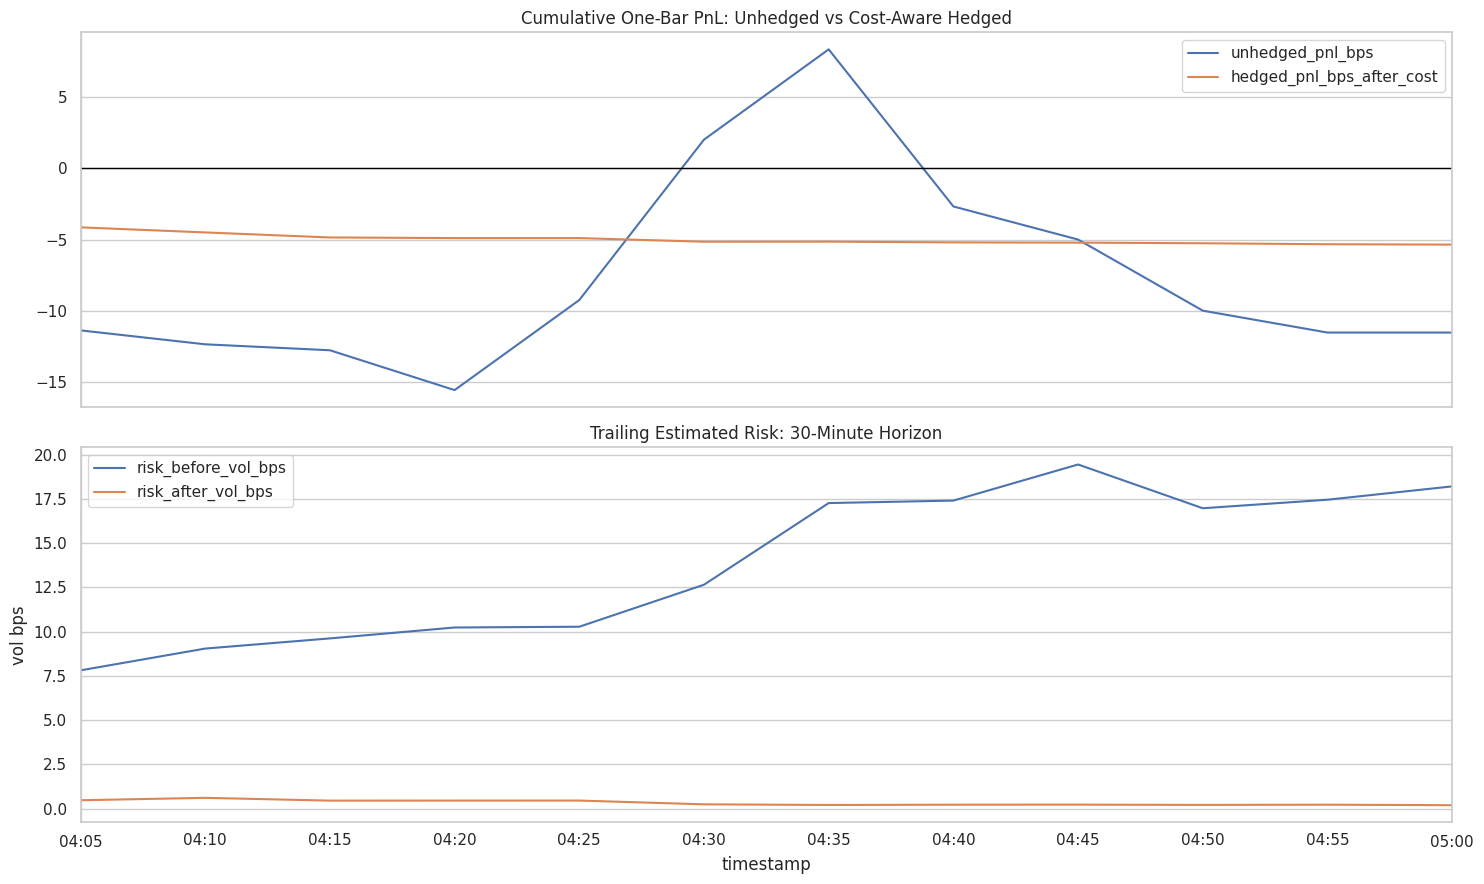

In [22]:
if not rolling_sim.empty:
    fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
    rolling_sim[["unhedged_pnl_bps", "hedged_pnl_bps_after_cost"]].cumsum().plot(ax=axes[0])
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_title("Cumulative One-Bar PnL: Unhedged vs Cost-Aware Hedged")
    rolling_sim[["risk_before_vol_bps", "risk_after_vol_bps"]].plot(ax=axes[1])
    axes[1].set_title(f"Trailing Estimated Risk: {HEDGE_HORIZON_MINUTES}-Minute Horizon")
    axes[1].set_ylabel("vol bps")
    plt.tight_layout()
else:
    print("Not enough return rows for rolling hedge simulation")

## Optional Save

In [23]:
if SAVE_OUTPUTS:
    out_dir = FEATURE_ROOT / DATE / f"bar_{BAR_MINUTES}m" / "hedging"
    out_dir.mkdir(parents=True, exist_ok=True)
    price_panel.to_parquet(out_dir / "hedge_price_panel.parquet")
    returns.to_parquet(out_dir / "hedge_returns.parquet")
    cov_horizon.to_parquet(out_dir / "hedge_covariance.parquet")
    hedge_universe.to_parquet(out_dir / "hedge_universe.parquet")
    hedge_costs.to_parquet(out_dir / "hedge_costs.parquet")
    hedge_plan.to_parquet(out_dir / "hedge_plan.parquet")
    hedge_risk_summary.to_parquet(out_dir / "hedge_risk_summary.parquet")
    if "rolling_sim" in globals() and not rolling_sim.empty:
        rolling_sim.to_parquet(out_dir / "rolling_hedge_simulation.parquet")
    if "rolling_summary" in globals() and not rolling_summary.empty:
        rolling_summary.to_parquet(out_dir / "rolling_hedge_summary.parquet")
    print(f"wrote hedging outputs to {out_dir}")
else:
    print("SAVE_OUTPUTS is false; nothing written")

SAVE_OUTPUTS is false; nothing written


## Interpretation Notes

- The pair-spread reduction is an inverse-risk diagnostic: it estimates how much of an inventory can be explained by hedgeable cross-venue spread vectors.
- The cost-aware hedge is a live-action approximation: it recommends signed hedge trades after charging spread, funding, basis, and liquidity penalties.
- With the current partial day, covariance/PCA numbers are only a pipeline check. Re-run this after several complete days before trusting hedge ratios.
- The rolling simulation applies a one-step-forward hedge with turnover costs; use it for workflow checks now, and for walk-forward comparisons once we have complete days.